In [2]:
LOCATION = 'Гатчинский муниципальный округ (бывш. район) (Ленинградская область)'
YEAR = 2026
INITIAL_PLAN = {
    'социально-экономический анализ': [
        'демография', 
        'производительность труда', 
        'структура и динамика ВГП', 
        'рынок труда', 
        'рынок жилья и коммерческой недвижимости', 
        'бюджетная обеспеченность'
    ],
    'пространственный анализ': [
        'функциональная организация территории', 
        'структура землевладения', 
        'природноэкологический каркас', 
        'архитектурно-градостроительная среда'
    ],
    'транспортный анализ':[
        'городской и внешний пассажирский и грузовой транспорт',
        'парковки',
        'пешеходные зоны',
    ],
    'анализ инженерной инфраструктуры':[
        'водоснабжение и водоотведение', 
        'энергоснабжение', 
        'теплоснабжение',
    ]
}

# INITIAL_PLAN = """
# Диагностика экономического и пространственного состояния:
# - социально-экономический анализ (демография, производительность труда, структура и динамика ВГП, рынок труда, рынок жилья и коммерческой недвижимости, бюджетная обеспеченность);
# - пространственный анализ (функциональная организация территории, структура землевладения, природноэкологический каркас, архитектурно-градостроительная среда);
# - транспортный анализ (городской и внешний пассажирский и грузовой транспорт, парковки, пешеходные зоны);
# - анализ инженерной инфраструктуры (водоснабжение и водоотведение, энергоснабжение, теплоснабжение).
# """

## Graphs

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from operator import add

from src import Agent, llm
from pydantic import BaseModel, Field

### Plan revision graph

In [4]:
class PlanRevisionState(TypedDict):
    location : str
    year : int
    initial_plan : str
    critique : str
    revisited_plan : str

CRITICIZE_MESSAGE = """
Ты строгий критик.
Тебе необходимо сформулировать, какие вопросы не учтены в изначальном плане анализа территории.
---
КОНТЕКСТ:
- Территория: {location}
- Текущий год: {year}
---
ИЗНАЧАЛЬНЫЙ ПЛАН:
{initial_plan}
"""

def criticize_plan(state : PlanRevisionState):
    message = CRITICIZE_MESSAGE.format(**state)
    res = llm.invoke(message)
    return {
        'critique': res.content
    }

REVISIT_MESSAGE = """
Тебе необходимо скорректировать изначальный план анализа территории с учетом полученной критики.
---
ПРАВИЛА РАБОТЫ:
- Верни только окончательный план без лишних комментариев.
- Изначальный план должен ПОЛНОСТЬЮ присутствовать в окончательном варианте
---
ИЗНАЧАЛЬНЫЙ ПЛАН:
{initial_plan}
---
КРИТИКА:
{critique}
"""

def revisit_plan(state : PlanRevisionState):
    message = REVISIT_MESSAGE.format(**state)
    res = llm.invoke(message)
    return {
        'revisited_plan': res.content
    }

plan_revision_graph = StateGraph(PlanRevisionState)

plan_revision_graph.add_node('criticize', criticize_plan)
plan_revision_graph.add_node('revisit', revisit_plan)

plan_revision_graph.add_edge(START, 'criticize')
plan_revision_graph.add_edge('criticize', 'revisit')
plan_revision_graph.add_edge('revisit', END)

plan_revision_app = plan_revision_graph.compile()

### QA graph

planner -> worker -> summarizer

In [ ]:
class QAState(TypedDict):
    question : str
    _questions : list[str]
    _answers : Annotated[list[str], add]
    answer : str
    iterations : int
    _iteration : int

def invoke_qa_master(state : QAState):
    return {
        '_questions': [],
        '_answers': [],
        '_iteration': 0
    }    

QA_PLANNER_MESSAGE = """
Ты планировщик. 
Тебе необходимо сформировать перечень вопросов для других агента с целью формирования развернутого окончательного ответа на главный вопрос.
---
ПРАВИЛА РАБОТЫ:
- Проанализируй полученные к данному моменту результаты.
- Если результатов НЕДОСТАТОЧНО, сформулируй перечень вопросов для агентов на текущую итерацию.
- Если результатов ДОСТАТОЧНО, оставь перечень вопросов пустым.
- МАКСИМУМ 5 вопросов на итерацию.
---
ТРЕБОВАНИЯ К ВОПРОСАМ:
- Вопросы должны быть понятны агенту БЕЗ КОНТЕКСТА. Вся информация должна быть сформулирована и доступна в САМОМ ВОПРОСЕ. Например:
    - "Какая численность населения в г. Санкт-Петербург в 2026 году?"
- Вопросы должны быть атомарными и узконаправленными. Например:
    - "Какая динамика численности населения?"
    - "Какие объекты в сфере транспорта планируются к постройке?"
---
ГЛАВНЫЙ ВОПРОС:
{question}
---
ПОЛУЧЕННЫЕ РЕЗУЛЬТАТЫ:
{_answers}
"""

class QAPlannerResponse(BaseModel):
    questions : list[str] = Field(description='Перечень вопросов')

def invoke_qa_planner(state : QAState):
    message = QA_PLANNER_MESSAGE.format(**state)
    structured_llm = llm.with_structured_output(QAPlannerResponse)
    return {
        '_questions': structured_llm.invoke(message).questions
    }



{'_questions': ['Какова численность населения Гатчины в 2026 году?',
  'Какова возрастная структура населения Гатчины в 2026 году?',
  'Каковы основные демографические тенденции в Гатчине на 2026 год?',
  'Какова миграционная динамика населения Гатчины в 2026 году?',
  'Каковы прогнозы по рождаемости и смертности в Гатчине на 2026 год?']}

In [19]:
class QuestionState(TypedDict):
    question : str
    answers : Annotated[list[str], add]
    final_answer : str

AGENT_PROMPT = """
Вы агент по поиску информации.
Ответьте основываясь строго на данных из инструментов.
---
ПРАВИЛА РАБОТЫ:
- НЕ ОТВЕЧАЙ на основе общих знаний.
- НЕ ДАВАЙ рекомендаций или комментариев.
- Постарайся МАКСИМАЛЬНО раскрыть тему.
"""

def get_answer_question(tools : list):

    def answer_question(state : QuestionState):
        agent = Agent(system_prompt=AGENT_PROMPT, tools=tools)
        res = agent.invoke(state['question'])
        return {
            'answers': [res]
        }
    
    return answer_question

SUMMARIZE_MESSAGE = """
Дай ответ на вопрос основываясь ТОЛЬКО на контексте.
---
ПРАВИЛА РАБОТЫ:
- НЕ ОТВЕЧАЙ на основе общих знаний.
- НЕ ДАВАЙ рекомендаций или комментариев.
---
ВОПРОС:
{question}
---
КОНТЕКСТ:
{answers}
"""

def summarize_answer(state : QuestionState):
    message = SUMMARIZE_MESSAGE.format(**state)
    res = llm.invoke(message)
    return {
        'final_answer': res.content
    }

from src.tools import ddgs_tool
from src.store import Store

store = Store()

question_graph = StateGraph(QuestionState)

question_graph.add_node('summarize', summarize_answer)
question_graph.add_edge('summarize', END)

for i,tools in enumerate([[ddgs_tool], [ddgs_tool]]):
    name = f'answer_{i+1}'
    question_graph.add_node(name, get_answer_question(tools))
    question_graph.add_edge(START, name)
    question_graph.add_edge(name, 'summarize')

question_app = question_graph.compile()

In [21]:
question_app.invoke({
    'question': 'Гатчина динамика населения к 2026 году'
})

{'question': 'Гатчина динамика населения к 2026 году',
 'answers': ['По состоянию на 1 марта 2026 года, численность населения Гатчины составляет 91 685 человек. Из них 40 268 мужчин (43.92%) и 51 417 женщин (56.08%) [1](https://bdex.ru/naselenie/leningradskaya-oblast/gatchina/). Гатчина конкурирует за первое место по численности населения в Ленинградской области с городом Мурино, который также является городом-спутником Санкт-Петербурга [2](https://ru.wikipedia.org/wiki/Гатчина).\n\nВ 2026 году в Гатчине ожидается масштабное обновление инфраструктуры, включая крупные инвестиции и ремонт дорог, что может повлиять на дальнейшую динамику населения [3](https://peterburg2.ru/news/gatchina-stanet-vizitnoy-kartochkoy-lenoblasti-drozdenko-anonsiroval-masshtabnye-peremeny-226085.html). \n\nДемографическая ситуация в России в целом в 2026 году характеризуется снижением рождаемости и увеличением смертности, что может также отразиться на населении Гатчины [4](https://radio1.ru/articles/obschestvo/

### Analysis Graph

In [9]:
class AnalysisState(TypedDict):
    location : str
    year : int
    plan : str
    questions : list[str]
    question : str
    results : Annotated[list[str], add]

MANAGER_MESSAGE = """
Ты менеджер. 
Тебе необходимо сформировать перечень вопросов для других агента с целью формирования окончательного ответа на запрос.
---
ПРАВИЛА РАБОТЫ:
- Проанализируй полученные к данному моменту результаты.
- Если результатов НЕДОСТАТОЧНО, сформулируй перечень вопросов для агентов на текущую итерацию.
- Если результатов ДОСТАТОЧНО, оставь перечень вопросов пустым.
---
ТРЕБОВАНИЯ К ВОПРОСАМ:
- Вопросы должны быть понятны агенту БЕЗ КОНТЕКСТА. Вся информация должна быть сформулирована в самом вопросе.
- Вопросы должны быть атомарными и узконаправленными. Например:
    - "Какая динамика численности населения?"
    - "Какие объекты в сфере транспорта планируются к постройке?"
---
КОНТЕКСТ:
- Территория: {location}
- Текущий год: {year}
---
ЗАПРОС:
{plan}
---
ТЕКУЩИЕ РЕЗУЛЬТАТЫ:
{results}
"""

class ManagerResponse(BaseModel):
    questions : list[str] = Field(description='Перечень вопросов')

def generate_questions(state : AnalysisState):
    message = MANAGER_MESSAGE.format(**state)
    structured_llm = llm.with_structured_output(ManagerResponse)
    res = structured_llm.invoke(message)
    return {
        'questions': res.questions
    }

def choose_question(state : AnalysisState):
    questions = state['questions']
    question = questions[0]
    return {
        'questions': questions[1:],
        'question' : question
    }

def answer_question(state : AnalysisState):
    question = state['question']
    result = question_app.invoke({'question':question})['final_answer']
    return {
        'results': [result]
    }

analysis_graph = StateGraph(AnalysisState)

analysis_graph.add_node('generate', generate_questions)
analysis_graph.add_node('choose', choose_question)
analysis_graph.add_node('answer', answer_question)

analysis_graph.add_edge(START, 'generate')
analysis_graph.add_conditional_edges('generate', lambda s : 'choose' if len(s['questions']) > 0 else END, ['choose', END])
analysis_graph.add_edge('choose', 'answer')
analysis_graph.add_conditional_edges('answer', lambda s : 'choose' if len(s['questions']) > 0 else 'generate', ['choose', 'generate'])

analysis_app = analysis_graph.compile(debug=True)

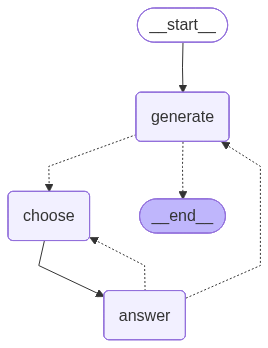

In [10]:
analysis_app

In [111]:
plan_revision_res = plan_revision_app.invoke({
    'location': LOCATION,
    'year': YEAR,
    'initial_plan': INITIAL_PLAN
})
print(plan_revision_res['revisited_plan'])

Диагностика экономического и пространственного состояния:
- социально-экономический анализ (демография, производительность труда, структура и динамика ВГП, рынок труда, рынок жилья и коммерческой недвижимости, бюджетная обеспеченность; уровни социальной неравенства и доступности социальных услуг, потребности различных групп населения);
- пространственный анализ (функциональная организация территории, структура землевладения, природноэкологический каркас, архитектурно-градостроительная среда; состояние объектов культурного наследия и их роль в экономике региона, возможности для развития туризма и культурных инициатив);
- транспортный анализ (городской и внешний пассажирский и грузовой транспорт, парковки, пешеходные зоны);
- анализ инженерной инфраструктуры (водоснабжение и водоотведение, энергоснабжение, теплоснабжение);
- анализ климатических изменений и их влияния на экономическое и пространственное состояние территории, меры по адаптации к климатическим изменениям;
- анализ экологич

In [112]:
res = analysis_app.invoke({
    'location': LOCATION,
    'year': YEAR,
    'plan': plan_revision_res['revisited_plan'],
})

[values] {'location': 'Гатчинский муниципальный округ (бывш. район) (Ленинградская область)', 'year': 2026, 'plan': 'Диагностика экономического и пространственного состояния:\n- социально-экономический анализ (демография, производительность труда, структура и динамика ВГП, рынок труда, рынок жилья и коммерческой недвижимости, бюджетная обеспеченность; уровни социальной неравенства и доступности социальных услуг, потребности различных групп населения);\n- пространственный анализ (функциональная организация территории, структура землевладения, природноэкологический каркас, архитектурно-градостроительная среда; состояние объектов культурного наследия и их роль в экономике региона, возможности для развития туризма и культурных инициатив);\n- транспортный анализ (городской и внешний пассажирский и грузовой транспорт, парковки, пешеходные зоны);\n- анализ инженерной инфраструктуры (водоснабжение и водоотведение, энергоснабжение, теплоснабжение);\n- анализ климатических изменений и их влияния

KeyboardInterrupt: 

## Agents

In [25]:
from src import Agent, llm
from pydantic import BaseModel, Field

### Planner

In [ ]:
PLAN_CRITIC_

llm.invoke(f'Какие вопросы следует учесть вдобавок к текущему плану при генеральном планировании? План: {INITIAL_PLAN}')

AIMessage(content='При генеральном планировании важно учитывать широкий спектр факторов, которые могут повлиять на развитие территории. В дополнение к уже перечисленным аспектам, можно рассмотреть следующие вопросы:\n\n1. **Экологический анализ**:\n   - Оценка воздействия на окружающую среду (ОВОС).\n   - Устойчивое использование природных ресурсов.\n   - Защита природных экосистем и биоразнообразия.\n\n2. **Социальный анализ**:\n   - Уровень жизни населения и доступ к социальным услугам (образование, здравоохранение, культура).\n   - Социальная инфраструктура (школы, больницы, спортивные и культурные учреждения).\n   - Участие граждан в планировании и принятии решений.\n\n3. **Культурный и исторический анализ**:\n   - Сохранение исторического наследия и культурных объектов.\n   - Влияние культурных факторов на развитие территории.\n\n4. **Экономический анализ**:\n   - Привлечение инвестиций и развитие предпринимательства.\n   - Анализ конкурентоспособности региона.\n   - Развитие новы

In [ ]:


class Subtopic(BaseModel):
    name : str = Field(description='Название подтемы')
    questions : list[str] = Field(description='Перечень вопросов')

class Topic(BaseModel):
    name : str = Field(description='Название темы')
    subtopics : list[Subtopic] = Field(description='Перечень подтем')

class PlannerResponse(BaseModel):
    topics : list[Topic] = Field(description='Перечень тем')

structured_llm = llm.with_structured_output(PlannerResponse)
structured_llm.invoke(PLANNER_PROMPT.format(
    location=LOCATION,
    year=YEAR,
    plan=INITIAL_PLAN
)).model_dump()

{'topics': [{'name': 'Социально-экономический анализ',
   'subtopics': [{'name': 'Демография',
     'questions': ['Какова численность населения Гатчинского муниципального округа в 2026 году?',
      'Какова возрастная структура населения?',
      'Каковы миграционные процессы в округе?',
      'Каковы показатели рождаемости и смертности?']},
    {'name': 'Производительность труда',
     'questions': ['Какова средняя производительность труда в ключевых отраслях?',
      'Каковы факторы, влияющие на производительность труда?',
      'Каковы тенденции в изменении производительности труда за последние годы?']},
    {'name': 'Структура и динамика ВГП',
     'questions': ['Какова структура валового городского продукта?',
      'Каковы основные сектора экономики, формирующие ВГП?',
      'Какова динамика ВГП за последние 5 лет?']},
    {'name': 'Рынок труда',
     'questions': ['Каковы уровни безработицы в округе?',
      'Каковы основные профессии и специальности, востребованные на рынке тру

In [29]:
PlannerResponse(topics=['социально-экономический анализ', 'демография', 'производительность труда', 'структура и динамика ВГП', 'рынок труда', 'рынок жилья и коммерческой недвижимости', 'бюджетная обеспеченность', 'пространственный анализ', 'функциональная организация территории', 'структура землевладения', 'природноэкологический каркас', 'архитектурно-градостроительная среда', 'транспортный анализ', 'городской и внешний пассажирский и грузовой транспорт', 'парковки', 'пешеходные зоны', 'анализ инженерной инфраструктуры', 'водоснабжение и водоотведение', 'энергоснабжение', 'теплоснабжение']).model_dump()

{'topics': ['социально-экономический анализ',
  'демография',
  'производительность труда',
  'структура и динамика ВГП',
  'рынок труда',
  'рынок жилья и коммерческой недвижимости',
  'бюджетная обеспеченность',
  'пространственный анализ',
  'функциональная организация территории',
  'структура землевладения',
  'природноэкологический каркас',
  'архитектурно-градостроительная среда',
  'транспортный анализ',
  'городской и внешний пассажирский и грузовой транспорт',
  'парковки',
  'пешеходные зоны',
  'анализ инженерной инфраструктуры',
  'водоснабжение и водоотведение',
  'энергоснабжение',
  'теплоснабжение']}

In [5]:
PLANNER_PROMPT = """
Ты планировщик. Исходя из запроса пользователя и текущих результатов:
- Реши, достаточно ли результатов для выдачи финального ответа.
- Если информации НЕДОСТАТОЧНО, сформулируй перечень вопросов для других агентов.
- Если информации ДОСТАТОЧНО, оставь перечень вопросов пустым.
"""

PLANNER_MESSAGE = """
Запрос:
{query}
---
Текущие результаты:
{results}
"""

class PlannerResponse(BaseModel):
    questions : list[str] = Field(description='Перечень вопросов')

planner_agent = Agent(system_prompt=PLANNER_PROMPT, response_format=PlannerResponse)

def invoke_planner(query : str, results : list) -> list[str]:
    res = planner_agent.invoke(PLANNER_MESSAGE.format(
        query=query,
        results=results
    ))
    return res.questions

In [ ]:
questions = invoke_planner(query, [])
questions

In [ ]:
from src.tools import ddgs_tool
from src.store import Store

store = Store()

AGENT_PROMPT = """
Вы агент по поиску информации.
Ответьте основываясь строго на данных из инструментов.
---
ПРАВИЛА РАБОТЫ:
- НЕ ОТВЕЧАЙ на основе общих знаний.
- НЕ ДАВАЙ рекомендаций или комментариев.
"""

web_agent = Agent(
    system_prompt=AGENT_PROMPT,
    tools=[ddgs_tool],
    # debug=True,
)

doc_agent = Agent(
    system_prompt=AGENT_PROMPT,
    tools=[store.tool],
    # debug=True,
)

JUDGE_PROMPT="""

"""

judge_agent = Agent(
    system_prompt=JUDGE_PROMPT,
    is_checkpointer=True
)


for i in range(3):
    for a in [web_agent, doc_agent]:
        m = a.invoke([m for m in messages[-1:]])
        messages.append(m)
        print(m)

На 1 января 2023 года численность населения Гатчинского муниципального округа составляет 230,352 человека. Из них 58,63% проживают в городских условиях, включая такие населенные пункты, как Гатчина, Коммунар, Вырица и другие. 

В округе расположено 240 населённых пунктов, среди которых 6 городских (2 города и 4 городских посёлка) и 234 сельских населённых пункта. 

Демографические показатели показывают, что Гатчинский округ имеет высокие показатели рождаемости и активно развивается, что позволяет ему претендовать на звание "Семейной столицы" Ленинградской области.
На 1 января 2023 года численность населения Гатчинского муниципального округа составляет 230,352 человека. Из них 58,63% проживают в городских условиях, включая населенные пункты, такие как Гатчина, Коммунар, Вырица и другие. В округе расположено 240 населённых пунктов, среди которых 6 городских (2 города и 4 городских посёлка) и 234 сельских населённых пункта. Демографические показатели указывают на высокие показатели рождае

In [15]:
messages

['На 1 января 2023 года численность населения Гатчинского муниципального округа составляет 230,352 человека. Из них 58,63% проживают в городских условиях, включая такие населенные пункты, как Гатчина, Коммунар, Вырица и другие. \n\nВ округе расположено 240 населённых пунктов, среди которых 6 городских (2 города и 4 городских посёлка) и 234 сельских населённых пункта. \n\nДемографические показатели показывают, что Гатчинский округ имеет высокие показатели рождаемости и активно развивается, что позволяет ему претендовать на звание "Семейной столицы" Ленинградской области.',
 'На 1 января 2023 года численность населения Гатчинского муниципального округа составляет 230,352 человека. Из них 58,63% проживают в городских условиях, включая населенные пункты, такие как Гатчина, Коммунар, Вырица и другие. В округе расположено 240 населённых пунктов, среди которых 6 городских (2 города и 4 городских посёлка) и 234 сельских населённых пункта. Демографические показатели указывают на высокие показат

In [ ]:
SUMMARIZER_PROMPT = """
Дай ответ на вопрос, основываясь ТОЛЬКО на ответах других агентов. 
---
ПРАВИЛА РАБОТЫ:
- НЕ ОТВЕЧАЙ на основе общих знаний.
- НЕ ДАВАЙ рекомендаций или комментариев.
- Ответ должен быть ФИНАЛЬНЫМ.
"""

summarizer = Agent(
    system_prompt=SUMMARIZER_PROMPT,
)



In [ ]:
results = []

for i in range(3):
    questions = invoke_planner(query, results)
    
    if len(questions) == 0:
        break

    for question in questions:
        answers = [a.invoke(question) for a in [web_agent, doc_agent]]
        

NameError: name 'tasks' is not defined

In [73]:
tasks

['Какова демографическая ситуация в Гатчинском муниципальном округе в 2026 году?',
 'Какова производительность труда в Гатчинском муниципальном округе в 2026 году?',
 'Какова структура и динамика валового городского продукта (ВГП) в Гатчинском муниципальном округе в 2026 году?',
 'Каков рынок труда в Гатчинском муниципальном округе в 2026 году?',
 'Каков рынок жилья и коммерческой недвижимости в Гатчинском муниципальном округе в 2026 году?',
 'Какова бюджетная обеспеченность Гатчинского муниципального округа в 2026 году?']

In [ ]:
web_agent.invoke('')

'Гатчинский муниципальный округ — это муниципальное образование в центральной части Ленинградской области России, с административным центром в городе Гатчина. Он был образован в мае 2024 года и является правопреемником администрации Гатчинского муниципального района. \n\nДополнительную информацию можно найти по следующим ссылкам:\n- [Гатчинский муниципальный округ — Википедия](https://ru.wikipedia.org/wiki/Гатчинский_муниципальный_округ)\n- [Гатчинский муниципальный округ — Энциклопедия Руниверсалис](https://руни.рф/Гатчинский_муниципальный_округ)\n- [Решение Совета депутатов Гатчинского муниципального округа](https://base.garant.ru/410985970/)'

In [ ]:
from src import llm

llm.invoke('Тебе необходимо')

In [ ]:
web_result = web_agent.invoke([])

[values] {'messages': []}


In [4]:
web_result = web_agent.invoke(query)
doc_agent = doc_agent.invoke(query)

[values] {'messages': [HumanMessage(content='\nГатчинский муниципальный округ (бывш. район) (Ленинградская область) - 2026 год\n\nСоциально-экономический анализ:\n- демография\n- производительность труда\n- структура и динамика ВГП\n- рынок труда\n- рынок жилья и коммерческой недвижимости\n- бюджетная обеспеченность\n \n', additional_kwargs={}, response_metadata={}, id='16035801-43c3-4448-881a-b7498d59b56c')]}


KeyboardInterrupt: 

In [ ]:
for i in range(3):
    

## Agents

### Planner

In [3]:
from src import llm
from pydantic import BaseModel, Field

class PlannerResponse(BaseModel):
    subtopics : list[str] = Field(description='Перечень подтем')

PLANNER_MESSAGE = """
Ты планировщик. Твоя задача разбить тему на подтемы. Перечисли только подтемы без лишних комментариев
---
Тема:
{topic}
"""

def invoke_planner(topic) -> list[str]:
    structured_llm = llm.with_structured_output(PlannerResponse)
    message = PLANNER_MESSAGE.format(topic=topic)
    return structured_llm.invoke(message).subtopics

In [4]:
subtopics = invoke_planner(TOPICS[0])
print(subtopics)

['Численность населения', 'Возрастная структура', 'Половая структура', 'Миграционные процессы', 'Рождаемость и смертность', 'Семейные структуры', 'Уровень образования', 'Занятость и безработица', 'Социальные группы и их характеристики', 'Этнический состав населения']


### Web

[values] {'messages': [HumanMessage(content='\nТема: \nСоциально-экономический анализ Гатчинский муниципальный округ (бывш. район) (Ленинградская область). Тема: Демография\n---\nПодтема:\nЧисленность населения\n', additional_kwargs={}, response_metadata={}, id='1fe72aad-8cb2-40f1-927d-102d25628431')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 174, 'total_tokens': 203, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_a5086b7b9a', 'id': 'gen-1775126896-JMhIu5PEZs9FEQtrFdUV', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d4dce-f1d1-7

'По состоянию на 1 октября 2023 года численность населения Гатчинского муниципального округа составляет 261 664 человека. Из этого числа городское население составляет 153 670 человек, что указывает на значительное преобладание городского населения в округе. \n\nГатчинский муниципальный округ включает в себя 240 населённых пунктов, среди которых 6 городских (включая 2 города и 4 городских посёлка) и 234 сельских населённых пункта. \n\nДанные о численности населения основаны на результатах Всероссийской переписи населения 2020 года и последующих оценках.'

### Docs

In [7]:
print(web)

По состоянию на 1 января 2024 года, численность населения Гатчинского муниципального округа составляет 261 522 человека, что составляет 12,85% от общей численности населения Ленинградской области. В городских условиях (включая Гатчину, Коммунар, Вырицу, Дружную Горку, Сиверский и Тайцы) проживает 58,63% населения округа.

В 2022 году численность населения Гатчины составила 87 626 человек, однако в 2022 году произошло увеличение на 5 058 человек, и на начало 2023 года население Гатчины достигло 92 684 жителей. Это изменение указывает на положительную динамику роста населения в регионе.

Демографическая политика в Гатчинском округе активно обсуждается, включая вопросы рождаемости и имен, которые дают новорожденным. Однако конкретные данные о рождаемости и других демографических показателях в 2023 году требуют дополнительного уточнения.

Для более подробной информации можно обратиться к официальным источникам, таким как [Википедия о Гатчинском муниципальном округе](https://ru.wikipedia.or

In [25]:
print(web)

Вот социально-экономический анализ демографической ситуации в Тюмени на 2023 год:

1. **Численность населения**: На 1 января 2023 года численность населения Тюмени составила 855 618 человек, что на 20,9 тысячи больше по сравнению с предыдущими данными. Город продолжает расти, и ожидается, что к 2025 году население достигнет 872 077 человек. [Источник](https://tmn.sm.news/chislennost-naseleniya-tyumeni-dostigla-855-tysyach-chelovek-71411-u3t5/).

2. **Возрастная структура**: Информация о конкретной возрастной структуре населения Тюмени в 2023 году не была найдена, но возрастная структура обычно анализируется для понимания демографических и социально-экономических процессов. [Источник](https://zaochnik.com/spravochnik/sotsiologija/demografija/vozrastnaja-struktura-naselenija/).

3. **Половая структура**: Половая структура населения также не была детализирована в найденных источниках, но она включает распределение по полу и может быть проанализирована на основе данных о численности мужчин

In [6]:
from src.tools import ddgs_tool
from src.agent import Agent
from src.llms import llm
from langchain.messages import SystemMessage, HumanMessage

from pydantic import BaseModel, Field

class PlannerResponse(BaseModel):
    questions : list[str] = Field(min_length=1, description='Перечень вопросов для агентов')

PLANNER_PROMPT = """
Ты — агент-планировщик. 
Твоя задача — разбить запрос пользователя на конкретные, атомарные подзадачи для выполнения другими агентами.
---
Правила работы:
1. Каждая подзадача должна быть сформулирована как четкий вопрос
2. Подзадачи должны быть атомарными — каждая охватывает ровно один аспект
3. Подзадачи должны быть независимыми (результат одной не требуется для другой)
4. Учитывай основную категорию и подкатегорию запроса — детализируй подкатегорию на подподкатегории
---
Примеры:
- запрос пользователя: демография
- подзадачи: 
    - сколько населения проживает в X?
    - какие показатели миграции в X?
    - ...
---
Запрос пользователя:
{query}
"""

RAG_PROMPT = """
Ты — агент, который отвечает на вопросы строго по данным из инструментов.

ЖЕСТКИЕ ПРАВИЛА (НАРУШЕНИЯ ЗАПРЕЩЕНЫ):

1. МАКСИМУМ 3 ВЫЗОВА ИНСТРУМЕНТОВ
   - После 3-го вызова ТЫ ОБЯЗАН немедленно сформировать ответ
   - Даже если данные неполные — отвечай тем, что есть
   - НЕ ПЫТАЙСЯ сделать 4-й вызов

2. НЕ ИСПОЛЬЗУЙ общие знания
   - Только информация из результатов вызовов инструментов
   - Если данных нет — так и напиши

3. НЕ ПОВТОРЯЙ вызовы с похожими параметрами
   - Если запрос не дал результатов — меняй подход, а не перефразируй

ПРИНУДИТЕЛЬНАЯ ОСТАНОВКА:
После каждого вызова считай: "Вызов №X из 3"
Когда X = 3 — СРАЗУ ПЕРЕХОДИ К ФОРМИРОВАНИЮ ОТВЕТА

---
Контекст:
{query}
---
Вопрос:
{question}
"""

SUMMARIZER_MESSAGE = """
Сформируй итоговый ответ на запрос пользователя, используя только ответы других агентов.

ОБЯЗАТЕЛЬНЫЕ ПРАВИЛА:
- Строго следуй формату запроса пользователя
- Можно использовать таблицы и структурированные блоки — это допустимо и приветствуется
- Не добавляй новые данные, прогнозы или внешние источники
- Не делай предположений и не заполняй пробелы самостоятельно
- Не упоминай процесс анализа, источники, записи или ход рассуждений
- Не добавляй рекомендации, планы действий или списки “что нужно сделать”
- Не комментируй полноту или неполноту данных

СОДЕРЖАНИЕ:
- Используй только факты, которые уже присутствуют во входных данных
- Если часть информации отсутствует — просто не включай её

СТИЛЬ:
- Развёрнутый аналитический ответ
- Можно использовать таблицы и разделы
- Без коротких ответов и без телеграфного стиля
- Без лишней воды
                           
Ответ должен быть финальным и не содержать комментариев о процессе его получения.
                           
ЗАПРЕЩЕНО:
- выводить любые данные, которых нет во входе
- делать прогнозы
- добавлять внешние знания
---
Запрос пользователя:
{query}
---
Предоставленная информация:
{answers}
"""

from tqdm import tqdm

def ask_question(query : str, question : str) -> list[str]:
    system_prompts = RAG_PROMPT.format(query=query, question=question)
    web_agent = Agent(system_prompt=system_prompts, tools=[ddgs_tool])
    # doc_agent = Agent(system_prompt=system_prompts, tools=[store.tool])
    answers = []
    for agent in [web_agent]: #doc_agent
        answer = agent.invoke([])
        answers.append(answer)
    return answers

def ask_query(query : str):
    planner_agent = Agent(PLANNER_PROMPT.format(query=query), response_format=PlannerResponse)
    questions = planner_agent.invoke([]).questions

    for question in questions:
        print(question)

    answers = []
    for question in tqdm(questions):
        results = ask_question(query, question)
        answers.extend(results)

    return llm.invoke(SUMMARIZER_MESSAGE.format(
        query=query,
        answers=answers
    ))

In [7]:
template = '{category} г. Гатчина, (Гатчинский муниципальный район/округ, Ленинградская область). Фокус: {subcategory}'

queries = []

for category,subcategories in QUESTIONS.items():
    for subcategory in subcategories:
        query = template.format(category=category, subcategory=subcategory)
        queries.append(query)

results = {}

In [8]:
for query in queries:
    if query in results:
        continue
    print(query)
    result = ask_query(query)
    results[query] = result

Социально-экономический анализ г. Гатчина, (Гатчинский муниципальный район/округ, Ленинградская область). Фокус: Демография
Какое общее население проживает в г. Гатчина?
Какова возрастная структура населения г. Гатчина?
Каковы показатели рождаемости в г. Гатчина?
Каковы показатели смертности в г. Гатчина?
Каковы миграционные потоки в и из г. Гатчина?
Каков уровень образования населения г. Гатчина?
Каковы основные этнические группы, проживающие в г. Гатчина?
Каковы показатели занятости и безработицы в г. Гатчина?
Каков средний доход на душу населения в г. Гатчина?
Каковы условия жизни и уровень жизни населения г. Гатчина?


 90%|█████████ | 9/10 [03:07<00:20, 20.84s/it]


DDGSException: ('error sending request for url (https://search.yahoo.com/search;_ylt=LVPDaJTAq1tkvrhsvswQIIi2;_ylu=2IT12Uab4BDuN8x4wU6NBUiF39S3SgfHiVhfd4FPYXI3Kok?p=%D1%83%D1%80%D0%BE%D0%B2%D0%B5%D0%BD%D1%8C+%D0%B6%D0%B8%D0%B7%D0%BD%D0%B8+%D0%BD%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F+%D0%93%D0%B0%D1%82%D1%87%D0%B8%D0%BD%D0%B0&btf=y)', 'https://search.yahoo.com/search;_ylt=LVPDaJTAq1tkvrhsvswQIIi2;_ylu=2IT12Uab4BDuN8x4wU6NBUiF39S3SgfHiVhfd4FPYXI3Kok?p=%D1%83%D1%80%D0%BE%D0%B2%D0%B5%D0%BD%D1%8C+%D0%B6%D0%B8%D0%B7%D0%BD%D0%B8+%D0%BD%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F+%D0%93%D0%B0%D1%82%D1%87%D0%B8%D0%BD%D0%B0&btf=y')

In [ ]:
print(results['Социально-экономический анализ г. Гатчина, (Гатчинский муниципальный район/округ, Ленинградская область). Фокус: Производительность труда'])

**Социально‑экономический анализ г. Гатчина (Гатчинский муниципальный район/округ, Ленинградская область) – Фокус : Производительность труда**

---

### 1. Доступные количественные сведения  

| Показатель | Данные из предоставленных источников | Примечание |
|------------|--------------------------------------|------------|
| **Средняя начисленная заработная плата (2023 г.)** | ≈ 11 400 рублей (рост почти 30 % к 2023 г.) | Данные из Википедии |
| **Численность занятого населения в экономике** | <table><tr><th>Период (год)</th><th>Тыс. чел.</th></tr><tr><td>1‑й год*</td><td>46 314</td></tr><tr><td>2‑й год*</td><td>46 988</td></tr><tr><td>3‑й год*</td><td>47 038</td></tr><tr><td>4‑й год*</td><td>47 256</td></tr><tr><td>5‑й год*</td><td>46 709</td></tr></table> | Точные годы не указаны; представлена последовательность значений для муниципального образования «Город Гатчина» |
| **Рост занятости** | Увеличение почти 2 % в год (по сравнению с предыдущим годом) | Оценка из статьи Википедии |

In [ ]:
import pickle

with open('results.pickle', 'wb') as file:
    pickle.dump(results, file)

In [ ]:
import pickle

with open('results.pickle', 'rb') as file:
    results = pickle.load(file)

In [ ]:
results = {k:v.content for k,v in results.items()}

In [ ]:
from pydantic import BaseModel, Field
from src import Agent

In [ ]:
GOAL_PROMPT = """
Ты — эксперт по стратегическому планированию территорий.
На основе полученных данных сформулируй:
- внешние и внутренние факторы развития,
- миссию,
- цели пространственного развития.

Правила работы:
- НЕ ОТВЕЧАЙ на основе собственных знаний. Используй данные.
- НЕ КОММЕНТИРУЙ пропуски в данных. Отвечай на основе того, что доступно.
- Отвечай ТОЛЬКО на русском языке.
- ИЗБЕГАЙ конкретных числовых показателей.
- Цели должны быть достижимы, но не обязаны быть соизмеримыми в текущей формулировке.
"""

GOAL_MESSAGE = """
Данные:
{data}
"""

class GoalResponse(BaseModel):
    external_factors : list[str] = Field(min_length=2, description='Внешние факторы развития')
    internal_factors : list[str] = Field(min_length=2, description='Внутренние факторы развития')
    mission : str = Field(description='Миссия')
    goals : list[str] = Field(min_length=3, max_length=5, description='Цели пространственного развития')
    # tasks : list[str] = Field(description='Задачи пространственного развития')

goal_agent = Agent(system_prompt=GOAL_PROMPT, response_format=GoalResponse, debug=True)
res = goal_agent.invoke(GOAL_MESSAGE.format(data=results))

[values] {'messages': [HumanMessage(content="\nДанные:\n{'Социально-экономический анализ г. Гатчина, (Гатчинский муниципальный район/округ, Ленинградская область). Фокус: Демография': '**Демографический профиль г.\\u202fГатчина и Гатчинского муниципального района (Ленинградская область)**  \\n\\n---\\n\\n### 1. Возрастная структура (данные «Положения о территориальном планировании Гатчинского муниципального района», 2023\\u202fг.)\\n\\n| Территория | 0‑14\\u202fлет | 15‑64\\u202fлет | 65\\u202fлет и старше |\\n|------------|----------|----------|-----------------|\\n| **Город Гатчина** | 13,0\\u202f% (≈\\u202f29,1\\u202fтыс. чел.) | 62,7\\u202f% (≈\\u202f140,2\\u202fтыс. чел.) | 24,3\\u202f% (≈\\u202f54,3\\u202fтыс. чел.) |\\n| **Гатчинский муниципальный район (включая город)** | 16,0\\u202f% (≈\\u202f41,8\\u202fтыс. чел.) | 56,0\\u202f% (≈\\u202f146,2\\u202fтыс. чел.) | 28,0\\u202f% (≈\\u202f73,0\\u202fтыс. чел.) |\\n\\n*Показатели отражают долю каждой возрастной группы от общего числ

In [ ]:
print(list(results.values())[0])

**Демографический профиль г. Гатчина и Гатчинского муниципального района (Ленинградская область)**  

---

### 1. Возрастная структура (данные «Положения о территориальном планировании Гатчинского муниципального района», 2023 г.)

| Территория | 0‑14 лет | 15‑64 лет | 65 лет и старше |
|------------|----------|----------|-----------------|
| **Город Гатчина** | 13,0 % (≈ 29,1 тыс. чел.) | 62,7 % (≈ 140,2 тыс. чел.) | 24,3 % (≈ 54,3 тыс. чел.) |
| **Гатчинский муниципальный район (включая город)** | 16,0 % (≈ 41,8 тыс. чел.) | 56,0 % (≈ 146,2 тыс. чел.) | 28,0 % (≈ 73,0 тыс. чел.) |

*Показатели отражают долю каждой возрастной группы от общего числа населения и соответствующие абсолютные оценки (тысяч человек).*

---

### 2. Половой состав (данные сайта bdex.ru, 2025 г.)

| Территория | Мужчины | % от общей численности | Женщины | % от общей численности |
|------------|---------|------------------------|---------|------------------------|
| **Город Гатчина** | ≈ 40 268 чел. | 43,9 % | ≈

In [ ]:
res.model_dump()

{'external_factors': ['Демографические изменения, включая старение населения и рост доли трудоспособного населения.',
  'Экономическая ситуация в регионе, включая уровень безработицы и среднюю заработную плату.',
  'Развитие транспортной инфраструктуры, включая доступность и качество транспортных услуг.',
  'Экологические факторы, включая состояние природных ресурсов и охраняемых территорий.'],
 'internal_factors': ['Наличие развитой промышленной базы и сектора услуг.',
  'Активное жилищное строительство и спрос на жилье.',
  'Разнообразие форм собственности на землю и возможность её использования.',
  'Наличие культурных и исторических объектов, способствующих развитию туризма.'],
 'mission': 'Создание комфортной и устойчивой городской среды, способствующей социальному и экономическому развитию Гатчины и Гатчинского района.',
 'goals': ['Увеличение доступности и качества социальных услуг для населения.',
  'Развитие инфраструктуры для поддержки экономического роста и повышения качеств